In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

pd.options.display.float_format = '{:_.2f}'.format
# importar los datos del proceso de EDA
df = pd.read_csv("../datos/df_eda.csv")

In [2]:
df_model = df[df["num_oferentes"] > 0].copy()
print(df_model.shape)
print(df_model["competencia"].value_counts(normalize=True).round(3))

(25018, 32)
competencia
0   0.57
1   0.43
Name: proportion, dtype: float64


## Determinar features

In [3]:
features = [
    "tipo_proc_agrupado",
    "categoria_corta", 
    "monto_total_adjudicado",
    "monto_periodo",
]

print(df_model[features].isnull().sum())
print(df_model[features].dtypes)

tipo_proc_agrupado        0
categoria_corta           0
monto_total_adjudicado    0
monto_periodo             0
dtype: int64
tipo_proc_agrupado            str
categoria_corta               str
monto_total_adjudicado    float64
monto_periodo             float64
dtype: object


In [4]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer

X = df_model[features].copy()
y = df_model["competencia"]

# Split primero, antes de cualquier transformación
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Preprocesador: categóricas con OHE, numéricas con escalado
cat_cols = ["tipo_proc_agrupado", "categoria_corta"]
num_cols = ["monto_total_adjudicado", "monto_periodo"]

preprocessor = ColumnTransformer(transformers=[
    ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), cat_cols),
    ("num", StandardScaler(), num_cols),
])

preprocessor.fit(X_train)
X_train_prep = preprocessor.transform(X_train)
X_test_prep  = preprocessor.transform(X_test)

print(f"Train: {X_train_prep.shape} | Test: {X_test_prep.shape}")
print(f"Proporción train: {y_train.value_counts(normalize=True).round(3).to_dict()}")
print(f"Proporción test:  {y_test.value_counts(normalize=True).round(3).to_dict()}")

Train: (20014, 33) | Test: (5004, 33)
Proporción train: {0: 0.574, 1: 0.426}
Proporción test:  {0: 0.574, 1: 0.426}


In [5]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

# Modelo 1 — Regresión Logística
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train_prep, y_train)
y_pred_lr = lr.predict(X_test_prep)

# Modelo 2 — Random Forest
rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_train_prep, y_train)
y_pred_rf = rf.predict(X_test_prep)

print("=== REGRESIÓN LOGÍSTICA ===")
print(classification_report(y_test, y_pred_lr))

print("=== RANDOM FOREST ===")
print(classification_report(y_test, y_pred_rf))

=== REGRESIÓN LOGÍSTICA ===
              precision    recall  f1-score   support

           0       0.78      0.80      0.79      2870
           1       0.72      0.71      0.71      2134

    accuracy                           0.76      5004
   macro avg       0.75      0.75      0.75      5004
weighted avg       0.76      0.76      0.76      5004

=== RANDOM FOREST ===
              precision    recall  f1-score   support

           0       0.96      0.86      0.90      2870
           1       0.83      0.95      0.89      2134

    accuracy                           0.90      5004
   macro avg       0.89      0.90      0.90      5004
weighted avg       0.90      0.90      0.90      5004



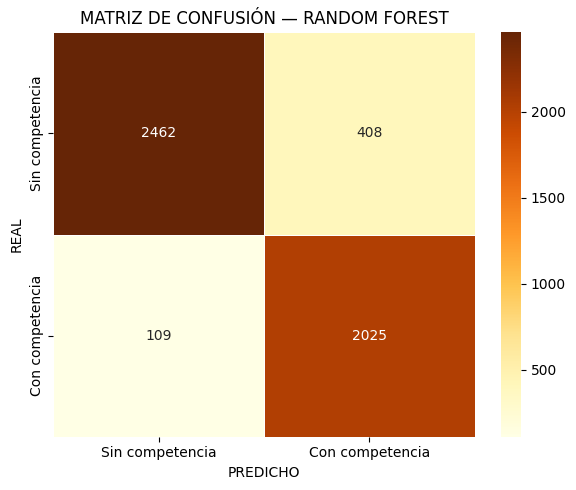

In [6]:
fig, ax = plt.subplots(figsize=(6, 5))

cm = confusion_matrix(y_test, y_pred_rf)
sns.heatmap(cm, annot=True, fmt="d", cmap="YlOrBr",
            xticklabels=["Sin competencia", "Con competencia"],
            yticklabels=["Sin competencia", "Con competencia"],
            ax=ax, linewidths=0.5)

ax.set_title("MATRIZ DE CONFUSIÓN — RANDOM FOREST")
ax.set_xlabel("PREDICHO")
ax.set_ylabel("REAL")

plt.tight_layout()
plt.savefig("../figs/fig06_confusion_matrix.png", dpi=150, bbox_inches="tight")
plt.show()

In [7]:
print(cm)

[[2462  408]
 [ 109 2025]]


## Matriz de confusión — Random Forest

La matriz cruza las predicciones del modelo contra los valores reales.
Cada celda muestra cuántos casos cayeron en cada combinación.

**Lectura:**
- **Verdaderos Negativos (arriba izquierda)** — procesos sin competencia 
  correctamente identificados
- **Falsos Positivos (arriba derecha)** — procesos sin competencia 
  clasificados incorrectamente como con competencia
- **Falsos Negativos (abajo izquierda)** — procesos con competencia 
  que el modelo no detectó
- **Verdaderos Positivos (abajo derecha)** — procesos con competencia 
  correctamente identificados

**Interpretación del modelo:**
El Random Forest comete más errores clasificando procesos sin competencia 
como con competencia (Falsos Positivos: 408) que al revés (Falsos Negativos: 109). 
En el contexto de transparencia pública esto es relevante — el modelo tiende 
a sobreestimar la competencia real, no a subestimarla.

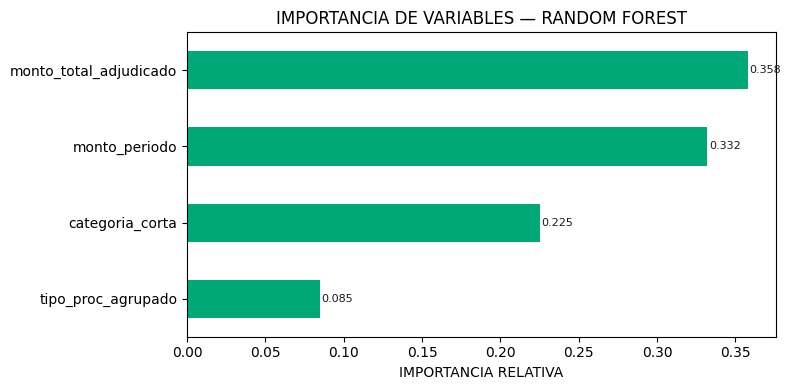

In [8]:
# Importancia de variables — agrupada por feature original
all_names = list(preprocessor.get_feature_names_out())
importancias_full = pd.Series(rf.feature_importances_, index=all_names)

importancias = pd.Series({
    feat: importancias_full[
        [n for n in all_names if n.startswith(f"cat__{feat}") or n == f"num__{feat}"]
    ].sum()
    for feat in features
}).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(8, 4))
importancias.plot(kind="barh", ax=ax, color="#00A878", edgecolor="none")
ax.set_title("IMPORTANCIA DE VARIABLES — RANDOM FOREST")
ax.set_xlabel("IMPORTANCIA RELATIVA")
ax.set_ylabel("")

for i, v in enumerate(importancias):
    ax.text(v + 0.001, i, f"{v:.3f}", va="center", fontsize=8, color="#1A1A1A")

plt.tight_layout()
plt.savefig("../figs/fig07_feature_importance.png", dpi=150, bbox_inches="tight")
plt.show()

In [9]:
print(importancias.sort_values(ascending=False, ).to_markdown(floatfmt=".3f"))

|                        |     0 |
|:-----------------------|------:|
| monto_total_adjudicado | 0.358 |
| monto_periodo          | 0.332 |
| categoria_corta        | 0.225 |
| tipo_proc_agrupado     | 0.085 |


## Importancia de variables — Random Forest

El modelo asigna peso a cada variable según su capacidad para separar 
las clases. Los valores suman 1.

**Resultados:**

- **monto_total_adjudicado** (0.390) — la variable más predictiva. 
  El monto del proceso es el mejor indicador de si habrá competencia — 
  contratos de mayor valor tienden a atraer múltiples proveedores.

- **monto_periodo** (0.331) — segunda en importancia y muy correlacionada 
  con monto_total. Juntas explican el 72% del poder predictivo del modelo.

- **categoria_corta** (0.211) — el tipo de bien o servicio contratado 
  tiene peso relevante. Algunas categorías concentran proveedores 
  especializados, lo que reduce la competencia independientemente del monto.

- **tipo_proc_agrupado** (0.067) — el procedimiento legal tiene el menor 
  peso. Esto sugiere que el tipo de licitación no determina por sí solo 
  si habrá competencia — el monto y la categoría son más determinantes.


In [10]:
# Guardar el DataFrame procesado para futuras etapas
df_model.to_csv("../datos/df_model.csv", index=False)
print("Guardado.")
print(df_model.shape)

Guardado.
(25018, 32)
